 Install required Python libraries for data processing, NLP, clustering,
 machine learning evaluation, and network/community analysis.

In [ ]:
pip -q install pandas numpy sentence-transformers hdbscan scikit-learn networkx python-louvain

Import libraries for data manipulation, numerical operations, and text cleaning using regular expressions.

In [ ]:
import pandas as pd
import numpy as np
import re

In [ ]:
from IPython.display import display

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CSV file upload

In [ ]:
CSV_PATH = "/content/drive/MyDrive/tiktok_comments.csv"
df = pd.read_csv(CSV_PATH)

print("Loaded CSV with shape:", df.shape)
df.head()

Loaded CSV with shape: (1226, 4)


,text,diggCount,replyCommentTotal,createTimeISO
0,I dont know you personally but I am very proud...,5,0,2025-10-07T00:16:28.000Z
1,UK most medical expenses are free we have an a...,2,2,2025-10-08T19:29:39.000Z
2,HIV meds in USA it’s 2400,4,4,2025-10-07T18:50:57.000Z
3,$35.000.00 annually in the United States,3,3,2025-10-06T22:11:08.000Z
4,"Unfortunately, here in the US, this is not true.",2,1,2025-10-06T21:38:08.000Z


Rename columns for consistency and convert timestamp values into datetime format for temporal analysis

In [ ]:
# Renaming columns
df = df.rename(columns={
    "diggCount": "diggcount",
    "replyCommentTotal": "reply_count",
    "createTimeISO": "timestamp"
})

# Parse timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

Clean comment text by removing URLs and extra whitespace while preserving emojis.
Remove empty and duplicate comments, then calculate engagement weights
Using logarithmic scaling of like counts

In [ ]:
# Clean text (keep emojis)
def clean_text(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"https?://\S+", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_clean"] = df["text"].apply(clean_text)

# Drop empties & duplicates
df = df[df["text_clean"].str.len() > 0]
df = df.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)

# Engagement weight
df["eng_weight"] = np.log1p(df["diggcount"])

print("Final shape:", df.shape)
display(df)

Final shape: (1162, 6)


,text,diggcount,reply_count,timestamp,text_clean,eng_weight
0,I dont know you personally but I am very proud...,5,0,2025-10-07 00:16:28+00:00,I dont know you personally but I am very proud...,1.791759
1,UK most medical expenses are free we have an a...,2,2,2025-10-08 19:29:39+00:00,UK most medical expenses are free we have an a...,1.098612
2,HIV meds in USA it’s 2400,4,4,2025-10-07 18:50:57+00:00,HIV meds in USA it’s 2400,1.609438
3,$35.000.00 annually in the United States,3,3,2025-10-06 22:11:08+00:00,$35.000.00 annually in the United States,1.386294
4,"Unfortunately, here in the US, this is not true.",2,1,2025-10-06 21:38:08+00:00,"Unfortunately, here in the US, this is not true.",1.098612
...,...,...,...,...,...,...
1157,I'm waiting for my miracle husband,0,0,2024-06-05 08:00:57+00:00,I'm waiting for my miracle husband,0.000000
1158,"Well, I’m happy for you…",1,0,2024-04-15 08:03:38+00:00,"Well, I’m happy for you…",0.693147
1159,She is very pretty 🩷🩷🩷,1,1,2024-04-15 02:57:26+00:00,She is very pretty 🩷🩷🩷,0.693147
1160,❣️,0,0,2024-05-06 03:13:15+00:00,❣️,0.000000


HDBSCAN

In [ ]:
import hdbscan

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Import the SentenceTransformer model for generating semantic text embeddings
and NumPy for numerical array operations.

In [ ]:
# EMBEDDINGS
from sentence_transformers import SentenceTransformer
import numpy as np

Load a pre-trained transformer model and generate semantic embeddings for each cleaned TikTok comment.

In [ ]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

X = model.encode(
    df["text_clean"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
).astype(np.float32)

print("Embeddings:", X.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Embeddings: (1162, 384)


Apply HDBSCAN clustering to group semantically similar comments and evaluate the number of clusters and proportion of noise/outlier comments.

In [ ]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=2,
    metric="euclidean",
    cluster_selection_method="eom"
)

df["cluster_hdb"] = clusterer.fit_predict(X)

n_clusters = df["cluster_hdb"].nunique() - (1 if -1 in df["cluster_hdb"].values else 0)
noise_pct = (df["cluster_hdb"] == -1).mean() * 100
print("HDBSCAN clusters:", n_clusters, "| noise %:", round(noise_pct, 1))

# --- QUICK CHECK: biggest clusters ---
display(df["cluster_hdb"].value_counts().head(10))

HDBSCAN clusters: 12 | noise %: 68.6


,count
cluster_hdb,
-1,797
8,72
10,72
3,36
9,35
11,28
7,25
6,21
2,18


Importing evaluation metrics

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

Filter out noise points and retain only valid clustered comments for clustering evaluation and analysis.

In [ ]:
# Ensure we have HDBSCAN labels
assert "cluster_hdb" in df.columns

# Mask non-noise points
mask = df["cluster_hdb"] != -1

X_core = X[mask]
labels_core = df.loc[mask, "cluster_hdb"].to_numpy()

print("Non-noise points:", len(labels_core))
print("Clusters (non-noise):", len(set(labels_core)))

Non-noise points: 365
Clusters (non-noise): 12


Calculate the silhouette score to evaluate how well-separated and semantically coherent the clusters are.

In [ ]:
sil_score = silhouette_score(
    X_core,
    labels_core,
    metric="cosine"  # IMPORTANT: match embedding similarity
)

print("Silhouette score (HDBSCAN, non-noise):", round(sil_score, 4))

Silhouette score (HDBSCAN, non-noise): 0.3391


Test multiple HDBSCAN parameter combinations and evaluate clustering performance
using silhouette score, Davies–Bouldin index, number of clusters, and noise fraction.

In [ ]:
results = []

for min_cluster_size in [5, 10, 15, 20, 30]:
    for min_samples in [1, 2, 5]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom"
        )

        labels = clusterer.fit_predict(X)
        mask = labels != -1

        # Need at least 2 clusters
        if mask.sum() < 2 or len(set(labels[mask])) < 2:
            continue

        sil = silhouette_score(X[mask], labels[mask], metric="cosine")
        db = davies_bouldin_score(X[mask], labels[mask])

        results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "n_clusters": len(set(labels[mask])),
            "noise_frac": (labels == -1).mean(),
            "silhouette": sil,
            "davies_bouldin": db
        })

results_df = pd.DataFrame(results).sort_values(
    ["silhouette", "davies_bouldin"],
    ascending=[False, True]
)

results_df

,min_cluster_size,min_samples,n_clusters,noise_frac,silhouette,davies_bouldin
14,30,5,2,0.861446,0.504538,0.903164
5,10,5,11,0.794320,0.498903,1.730692
8,15,5,6,0.809811,0.471807,1.813866
11,20,5,5,0.822719,0.467139,1.889146
13,30,2,4,0.786575,0.392748,2.016887
10,20,2,7,0.751291,0.372509,2.181792
12,30,1,5,0.759897,0.357866,2.236890
7,15,2,10,0.707401,0.350491,2.172441
4,10,2,12,0.685886,0.339106,2.145949
9,20,1,7,0.715146,0.319490,2.403238


Calculate the Davies–Bouldin index to measure cluster compactness and overlap between semantic clusters.

In [ ]:
db_score = davies_bouldin_score(
    X_core,
    labels_core
)

print("Davies–Bouldin index (HDBSCAN, non-noise):", round(db_score, 4))

Davies–Bouldin index (HDBSCAN, non-noise): 2.1459


Save clustered dataset to CSV for further analysis and store embeddings as a NumPy array for reuse in future modelling or visualisation.

In [ ]:
# SAVE
df.to_csv("tiktok_hdbscan_output.csv", index=False)

np.save("tiktok_embeddings.npy", X)

Recompute engagement weight by combining likes and replies, with replies weighted at half the value of likes using a logarithmic scale.

In [ ]:
ALPHA = 0.5  # replies count half as much as likes
df["eng_weight"] = np.log1p(df["diggcount"] + ALPHA * df["reply_count"])

Convert timestamps to datetime format and extract monthly periods to enable time-based aggregation and temporal analysis.

In [ ]:
# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

# Monthly bins
df["year_month"] = df["timestamp"].dt.to_period("M").astype(str)

/tmp/ipython-input-3496317058.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["timestamp"].dt.to_period("M").astype(str)


Filter dataset to include only non-noise points (valid clusters) for downstream temporal and cluster-based analysis.

In [ ]:
df_core = df[df["cluster_hdb"] != -1].copy()

Aggregate engagement metrics by month and cluster to analyse how discussion themes and engagement evolve over time.

In [ ]:
temporal_cluster_weight = (
    df_core
    .groupby(["year_month", "cluster_hdb"], as_index=False)
    .agg(
        n_comments=("text_clean", "count"),
        total_eng_weight=("eng_weight", "sum"),
        mean_eng_weight=("eng_weight", "mean"),
        median_eng_weight=("eng_weight", "median")
    )
)

Compute total monthly engagement and calculate each cluster’s relative share of engagement within each month.

In [ ]:
temporal_cluster_weight["month_total_eng"] = (
    temporal_cluster_weight
    .groupby("year_month")["total_eng_weight"]
    .transform("sum")
)

temporal_cluster_weight["relative_eng_weight"] = (
    temporal_cluster_weight["total_eng_weight"]
    / temporal_cluster_weight["month_total_eng"]
)

Export the temporal engagement summary by cluster to a CSV file for further analysis and reporting

In [ ]:
temporal_cluster_weight.to_csv(
    "temporal_cluster_engagement_weights.csv",
    index=False
)

print("Saved: temporal_cluster_engagement_weights.csv")

Saved: temporal_cluster_engagement_weights.csv


Convert year-month values back into datetime format to enable proper time-series plotting and temporal analysis

In [ ]:
temporal_cluster_weight["year_month"] = pd.to_datetime(
    temporal_cluster_weight["year_month"]
)

Import Matplotlib for data visualisation and plotting of trends over time.

In [ ]:
import matplotlib.pyplot as plt

Plot total engagement weight over time for each cluster to visualise how cluster visibility changes across months.

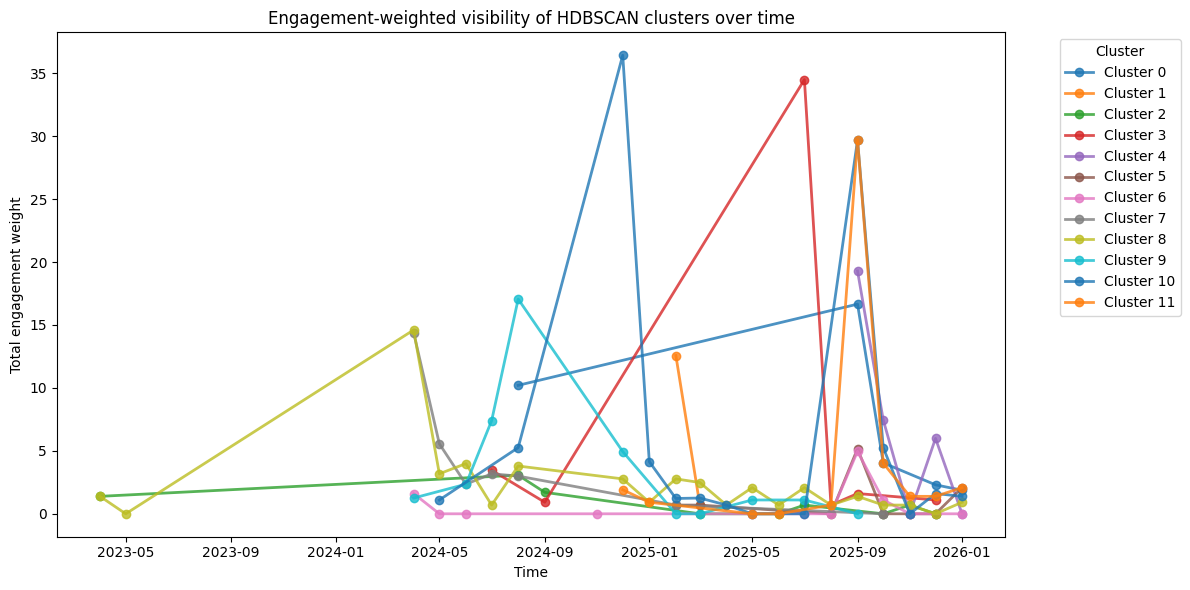

In [ ]:
plt.figure(figsize=(12, 6))

for cluster_id, sub in temporal_cluster_weight.groupby("cluster_hdb"):
    plt.plot(
        sub["year_month"],
        sub["total_eng_weight"],
        marker="o",
        linewidth=2,
        alpha=0.8,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Time")
plt.ylabel("Total engagement weight")
plt.title("Engagement-weighted visibility of HDBSCAN clusters over time")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Plot the proportion of total monthly engagement contributed by each cluster to compare relative attention across discussion themes over time

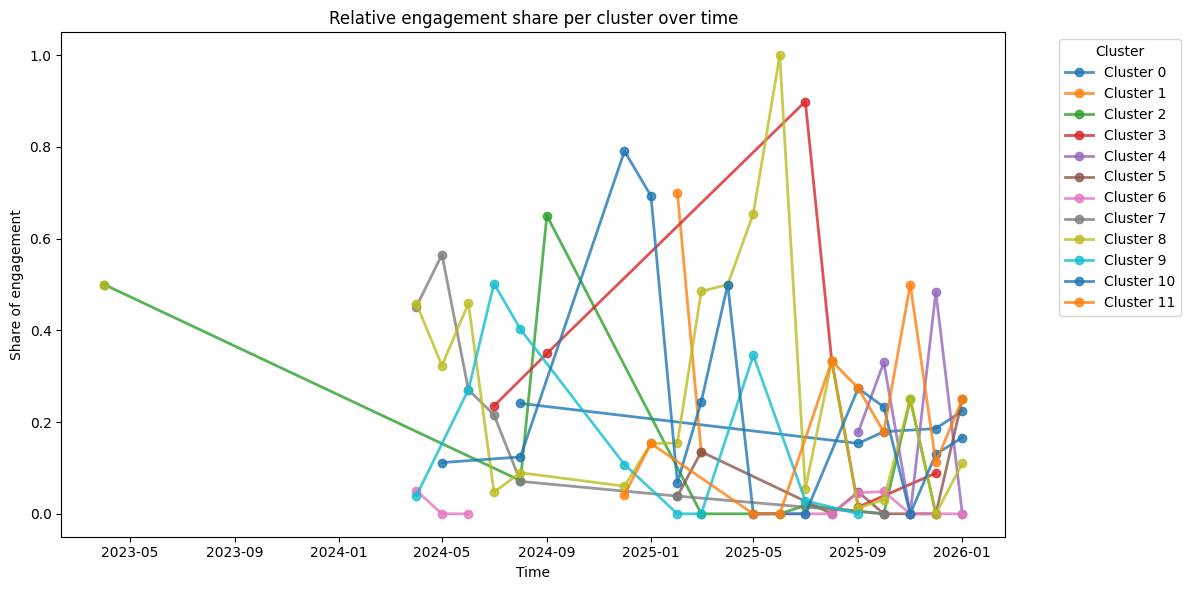

In [ ]:
plt.figure(figsize=(12, 6))

for cluster_id, sub in temporal_cluster_weight.groupby("cluster_hdb"):
    plt.plot(
        sub["year_month"],
        sub["relative_eng_weight"],
        marker="o",
        linewidth=2,
        alpha=0.8,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Time")
plt.ylabel("Share of engagement")
plt.title("Relative engagement share per cluster over time")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Aggregate total engagement and comment counts per cluster and rank clusters by overall engagement importance.

In [ ]:
cluster_importance = (
    temporal_cluster_weight
    .groupby("cluster_hdb")
    .agg(
        total_eng=("total_eng_weight", "sum"),
        n_comments=("n_comments", "sum")
    )
    .sort_values("total_eng", ascending=False)
)

cluster_importance

,total_eng,n_comments
cluster_hdb,,
10,88.036713,72
8,46.521557,72
3,42.274527,36
11,42.108645,28
9,35.205496,35
0,35.081218,14
4,32.738830,18
7,29.171322,25
1,13.269210,11


Identify the top 5 most engaged clusters and plot their engagement trends over time to compare how the most influential discussion themes evolve.

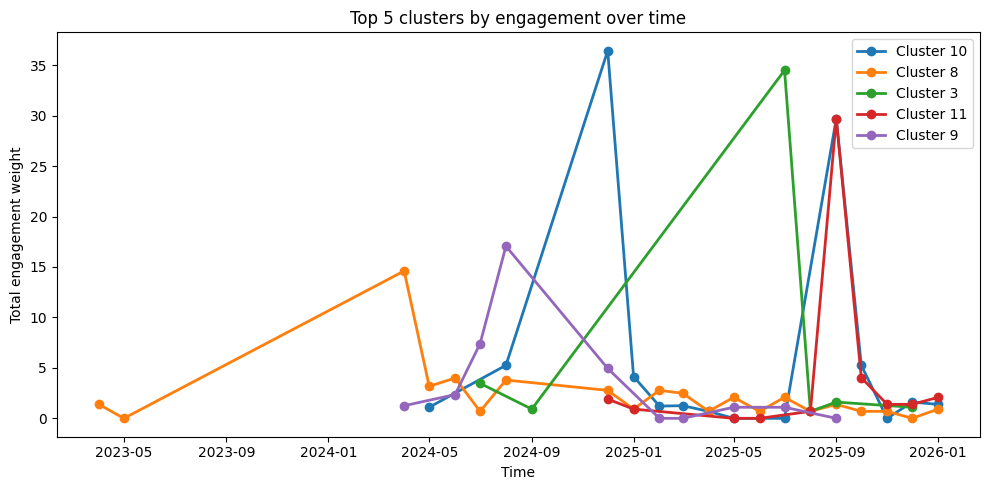

In [ ]:
top_clusters = cluster_importance.head(5).index.tolist()
plt.figure(figsize=(10, 5))

for c in top_clusters:
    sub = temporal_cluster_weight[
        temporal_cluster_weight["cluster_hdb"] == c
    ].sort_values("year_month")

    plt.plot(
        sub["year_month"],
        sub["total_eng_weight"],
        marker="o",
        linewidth=2,
        label=f"Cluster {c}"
    )

plt.xlabel("Time")
plt.ylabel("Total engagement weight")
plt.title("Top 5 clusters by engagement over time")
plt.legend()
plt.tight_layout()
plt.show()

Apply a 3-month rolling average to smooth engagement trends and reduce short-term fluctuations in cluster activity over time.

In [ ]:
temporal_cluster_weight["smoothed_eng"] = (
    temporal_cluster_weight
    .sort_values("year_month")
    .groupby("cluster_hdb")["total_eng_weight"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

Plot smoothed engagement trends for the top clusters to highlight longer-term patterns while reducing short-term volatility in engagement signals.

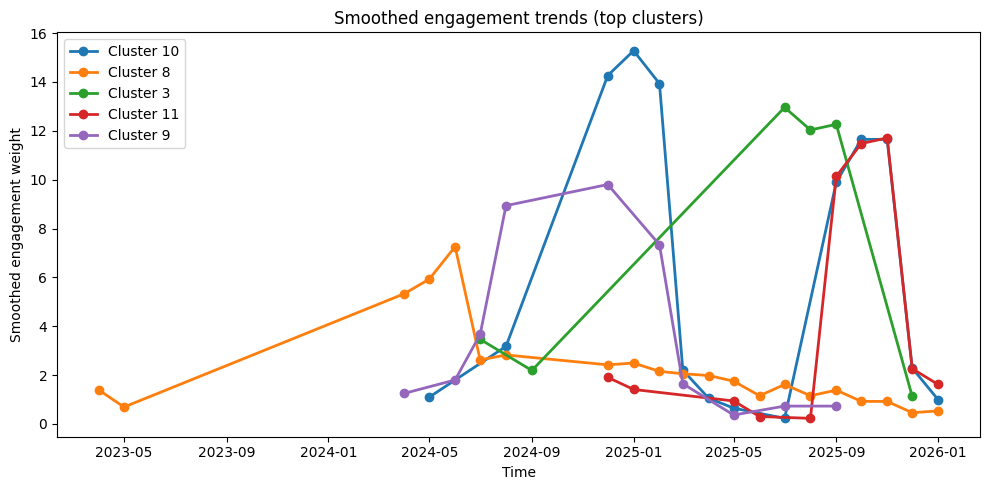

In [ ]:
plt.figure(figsize=(10, 5))

for c in top_clusters:
    sub = temporal_cluster_weight[
        temporal_cluster_weight["cluster_hdb"] == c
    ].sort_values("year_month")

    plt.plot(
        sub["year_month"],
        sub["smoothed_eng"],
        marker="o",
        linewidth=2,
        label=f"Cluster {c}"
    )

plt.xlabel("Time")
plt.ylabel("Smoothed engagement weight")
plt.title("Smoothed engagement trends (top clusters)")
plt.legend()
plt.tight_layout()
plt.show()

Install the NLTK library for natural language processing tasks such as sentiment analysis and tokenization.

In [ ]:
!pip -q install nltk

Import NLTK and the VADER sentiment analyzer for performing rule-based sentiment analysis on text data.

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

Download the VADER sentiment lexicon and initialise the sentiment analysis model.

In [ ]:
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Compute sentiment scores for each comment using VADER compound polarity scores.

In [ ]:
df["sentiment"] = df["text_clean"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

Aggregate sentiment statistics by cluster to analyse emotional tone including mean, median, and proportion of positive/negative comments.

In [ ]:
sentiment_by_cluster = (
    df[df["cluster_hdb"] != -1]
    .groupby("cluster_hdb")
    .agg(
        mean_sentiment=("sentiment", "mean"),
        median_sentiment=("sentiment", "median"),
        pos_frac=("sentiment", lambda x: (x > 0.05).mean()),
        neg_frac=("sentiment", lambda x: (x < -0.05).mean()),
        n_comments=("sentiment", "count")
    )
    .sort_values("n_comments", ascending=False)
)

sentiment_by_cluster

,mean_sentiment,median_sentiment,pos_frac,neg_frac,n_comments
cluster_hdb,,,,,
8,0.006117,0.00000,0.013889,0.000000,72
10,0.689860,0.68190,0.972222,0.000000,72
3,0.103669,0.00000,0.333333,0.166667,36
9,0.604320,0.59940,0.971429,0.000000,35
11,0.178693,-0.15130,0.428571,0.571429,28
7,0.589804,0.59940,0.920000,0.000000,25
6,0.698595,0.75060,0.952381,0.047619,21
2,0.136900,0.00000,0.222222,0.000000,18
4,-0.080261,0.00000,0.222222,0.444444,18


Import TF-IDF vectorizer for extracting important words/phrases from text and NumPy for numerical operations on feature matrices.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

Define a function to extract the most representative n-grams for a given cluster using TF-IDF scores to identify key terms and phrases within the cluster.

In [ ]:
def cluster_ngram_summary(df, cluster_id, topn=20):
    sub = df[df["cluster_hdb"] == cluster_id]

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,3),
        min_df=2,
        max_features=5000
    )

    tfidf = vec.fit_transform(sub["text_clean"])
    terms = np.array(vec.get_feature_names_out())
    mean_tfidf = tfidf.mean(axis=0).A1

    top_terms = terms[np.argsort(mean_tfidf)[::-1][:topn]]
    return top_terms

Set a target cluster ID and print the top representative n-grams to interpret the main themes within that cluster.

In [ ]:
cluster_id = 10  # change this
print(cluster_ngram_summary(df, cluster_id))

['love' 'thank' 'praying' 'strong' 'sharing' 'sending' 'brave'
 'thank sharing' 'sending love' 'story' 'hugs' 'sharing story' 'beautiful'
 'prayers' 'god' 'pray' 'courage' 'sending prayers' 'light' 'sorry']


Set a different cluster ID and extract its top n-grams to compare thematic differences between clusters.

In [ ]:
cluster_id = 3  # change this
print(cluster_ngram_summary(df, cluster_id))

['prep' 'daily' 'taking' 'injection' 'nhs' 'just' 'sex' 'everyday' 'like'
 'taking prep' 'option' 'daily prep' 'gay' 'available nhs' 'available'
 'years' 've' 'day' 'pills' 'week']


Select cluster 11 and display its most representative n-grams to understand the key topics and language used in this cluster.

In [ ]:
cluster_id = 11  # change this
print(cluster_ngram_summary(df, cluster_id))

['sorry' 'happened' 'sorry happened' 'thank' 'cody' 'smh' 'help' 'better'
 'heart' 'sorry cody' 'hope' 'deserve' 'feel' 'feel better'
 'im sorry happened' 'im' 'im sorry' 'sweet']


Select cluster 9 and extract its top n-grams to interpret dominant themes and keywords.

In [ ]:
cluster_id = 9  # change this
print(cluster_ngram_summary(df, cluster_id))

['bless' 'god' 'love' 'god bless' 'amazing' 'beautiful' 'wow' 'lovely'
 'wow amazing' 'wow nice' 'nice']


Install WordCloud

In [ ]:
!pip -q install wordcloud

Import WordCloud for visualising frequent terms in text data and Matplotlib for displaying the generated visualisations.

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Define a function to generate and display a word cloud for a given cluster to visually summarise the most frequent terms in that cluster.

In [ ]:
def plot_wordcloud_for_cluster(df, cluster_id):
    text = " ".join(df[df["cluster_hdb"] == cluster_id]["text_clean"])

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {cluster_id} – Word Cloud")
    plt.show()

Visualization

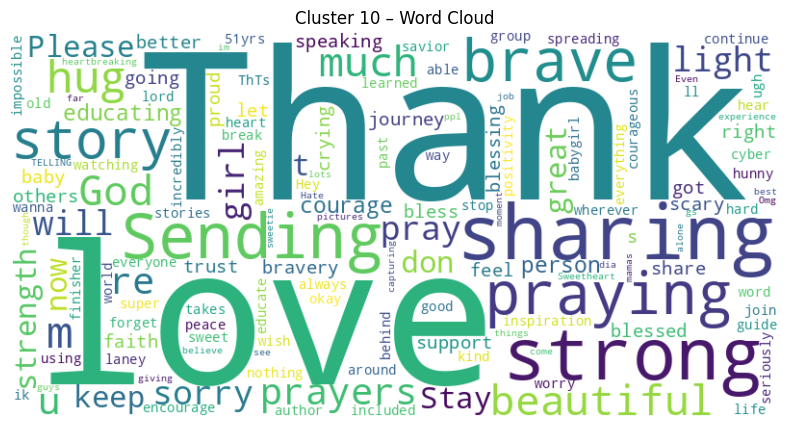

In [ ]:
plot_wordcloud_for_cluster(df, 10)

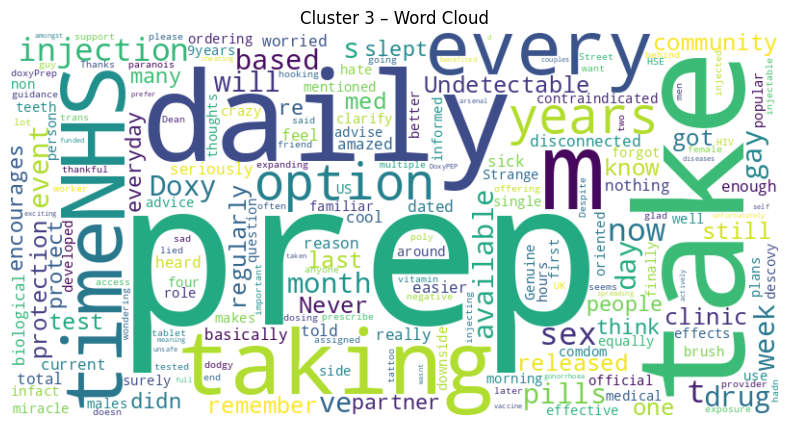

In [ ]:
plot_wordcloud_for_cluster(df, 3)

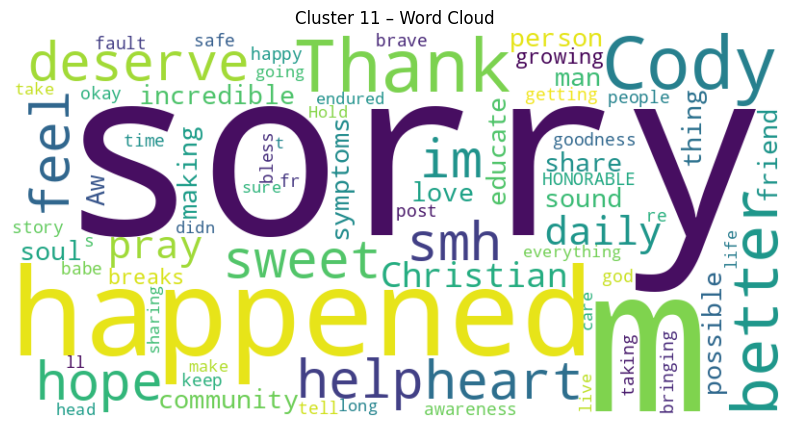

In [ ]:
plot_wordcloud_for_cluster(df, 11)

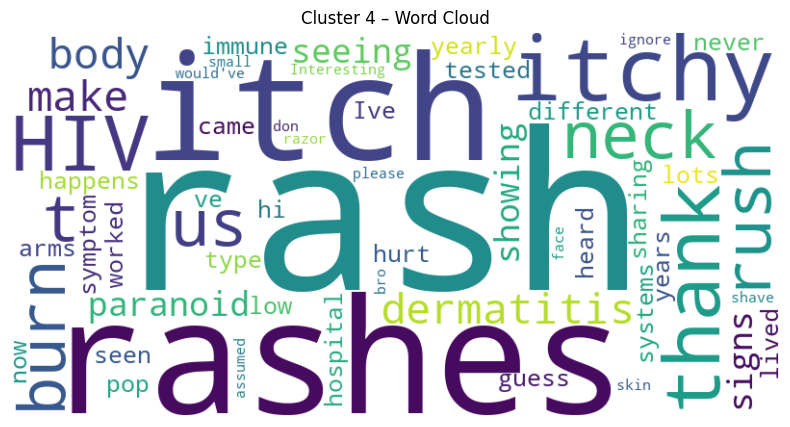

In [ ]:
plot_wordcloud_for_cluster(df, 4)

Import VADER sentiment analysis tool from NLTK for computing sentiment polarity scores.

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

Download the VADER sentiment lexicon, initialise the sentiment analyser,and compute sentiment scores for each comment using the compound polarity value.

In [ ]:
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["text_clean"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Convert continuous sentiment scores into categorical labels (positive, negative, neutral) based on VADER threshold values for easier interpretation and analysis.

In [ ]:
def sentiment_class(s):
    if s > 0.05:
        return "positive"
    elif s < -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment_label"] = df["sentiment_score"].apply(sentiment_class)

Create monthly time bins from timestamps for temporal analysis and filter out noise points to focus only on valid clusters.

In [ ]:
# Monthly bins
df["year_month"] = df["timestamp"].dt.to_period("M").astype(str)

# Exclude noise
df_core = df[df["cluster_hdb"] != -1].copy()

/tmp/ipython-input-1632748151.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["timestamp"].dt.to_period("M").astype(str)


Compute sentiment distribution over time by cluster and month and calculate the fraction of each sentiment category within each cluster-month group.

In [ ]:
sentiment_time = (
    df_core
    .groupby(["cluster_hdb", "year_month", "sentiment_label"])
    .size()
    .reset_index(name="count")
)

# Total comments per cluster-month
totals = (
    df_core
    .groupby(["cluster_hdb", "year_month"])
    .size()
    .reset_index(name="total")
)

sentiment_time = sentiment_time.merge(
    totals, on=["cluster_hdb", "year_month"]
)

sentiment_time["fraction"] = (
    sentiment_time["count"] / sentiment_time["total"]
)

Visualise how sentiment composition (positive, neutral, negative) changes over time for the top engagement clusters.

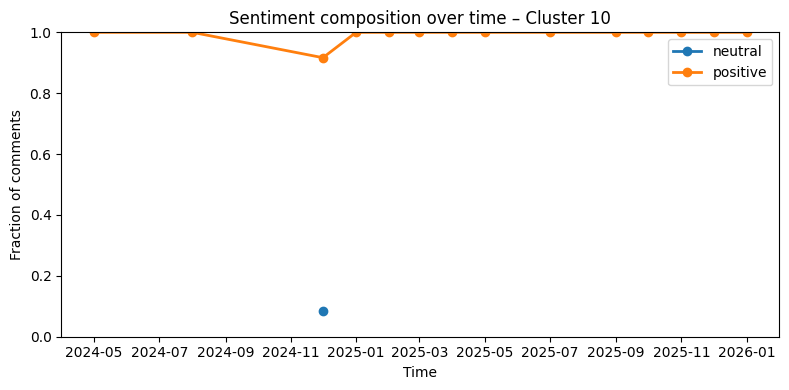

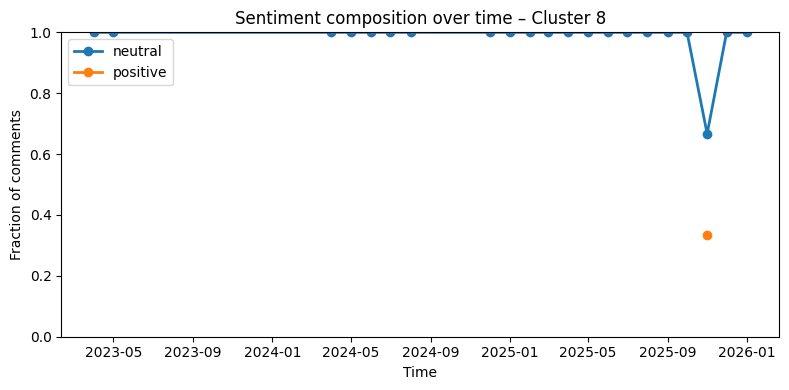

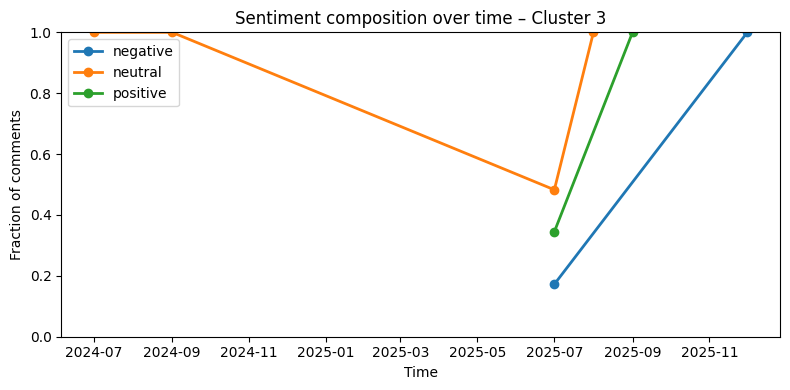

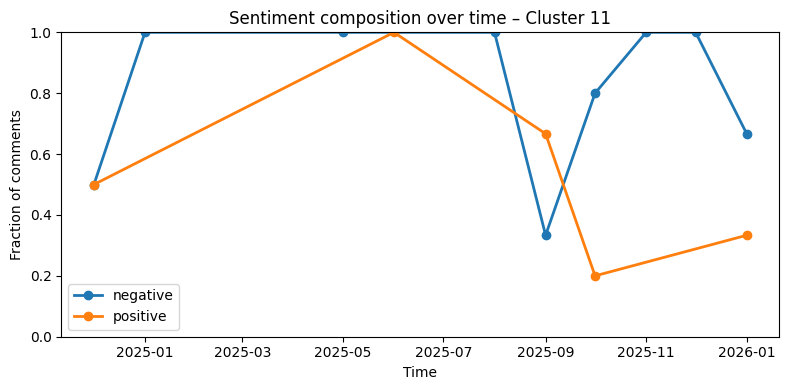

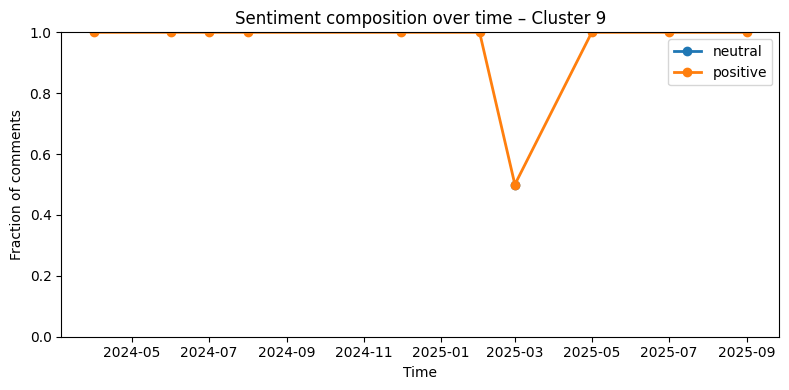

In [ ]:
# Pick top clusters by engagement (reuse what you already computed)
top_clusters = cluster_importance.head(5).index.tolist()

sentiment_order = ["negative", "neutral", "positive"]

for c in top_clusters:
    sub = sentiment_time[sentiment_time["cluster_hdb"] == c].copy()
    sub["year_month"] = pd.to_datetime(sub["year_month"])

    plt.figure(figsize=(8, 4))

    for label in sentiment_order:
        line = sub[sub["sentiment_label"] == label]
        if not line.empty:
            plt.plot(
                line["year_month"],
                line["fraction"],
                marker="o",
                linewidth=2,
                label=label
            )

    plt.ylim(0, 1)
    plt.xlabel("Time")
    plt.ylabel("Fraction of comments")
    plt.title(f"Sentiment composition over time – Cluster {c}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Validate that required columns exist before performing temporal sentiment analysis to prevent runtime errors during grouping and aggregation.

In [ ]:
# Ensure timestamp + sentiment already exist
assert "cluster_hdb" in df.columns
assert "sentiment_label" in df.columns
assert "timestamp" in df.columns

Extract year-month periods from timestamps to enable monthly aggregation for time-based sentiment and engagement analysis.

In [ ]:
df["year_month"] = df["timestamp"].dt.to_period("M").astype(str)

/tmp/ipython-input-3329283598.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["timestamp"].dt.to_period("M").astype(str)


Filter dataset to include only valid clusters (exclude noise) for sentiment and temporal analysis.

In [ ]:
df_core = df[df["cluster_hdb"] != -1].copy()

Filter dataset to include only valid clusters (exclude noise) for sentiment and temporal analysis.

In [ ]:
sentiment_time_all = (
    df_core
    .groupby(["cluster_hdb", "year_month", "sentiment_label"])
    .size()
    .reset_index(name="count")
)

# totals per cluster-month
totals = (
    df_core
    .groupby(["cluster_hdb", "year_month"])
    .size()
    .reset_index(name="total")
)

sentiment_time_all = sentiment_time_all.merge(
    totals, on=["cluster_hdb", "year_month"], how="left"
)

sentiment_time_all["fraction"] = (
    sentiment_time_all["count"] / sentiment_time_all["total"]
)

Filter dataset to include only valid clusters (exclude noise) for sentiment and temporal analysis.

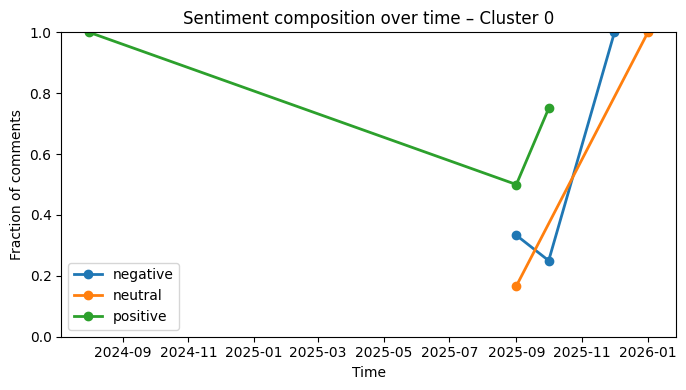

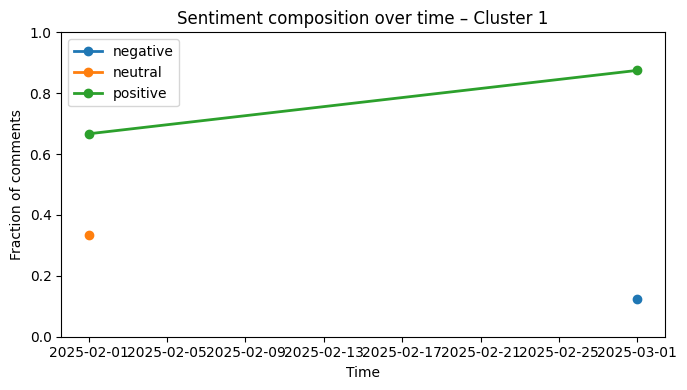

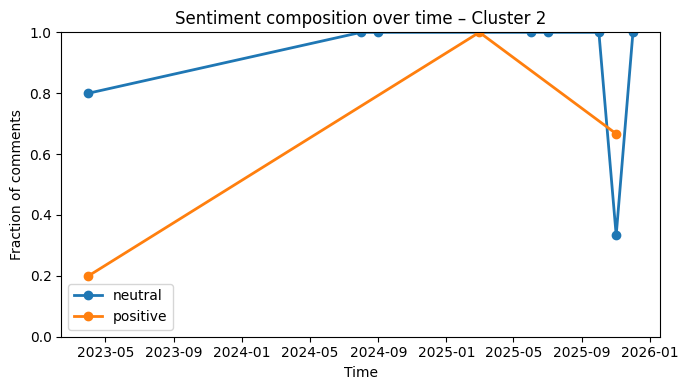

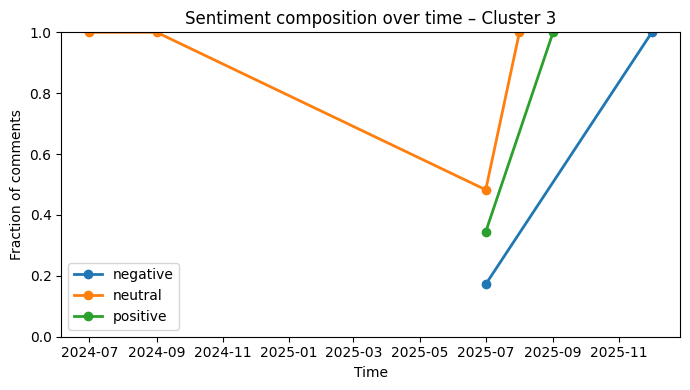

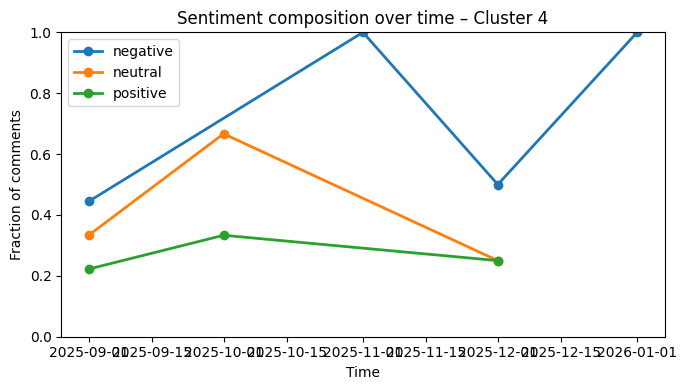

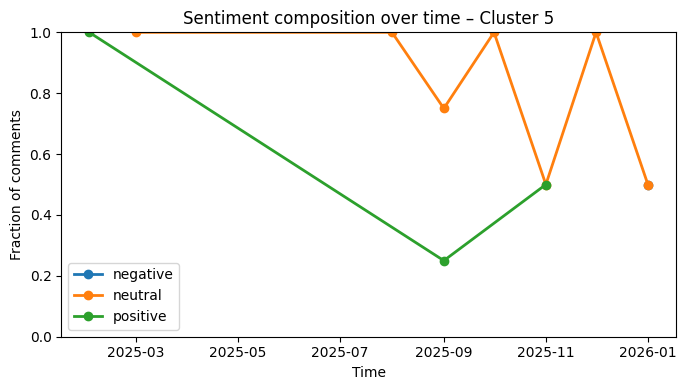

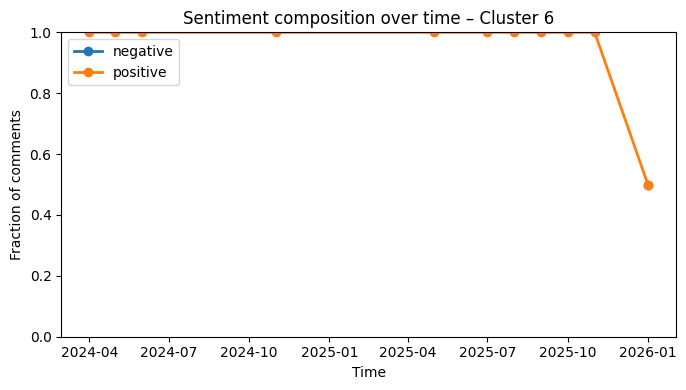

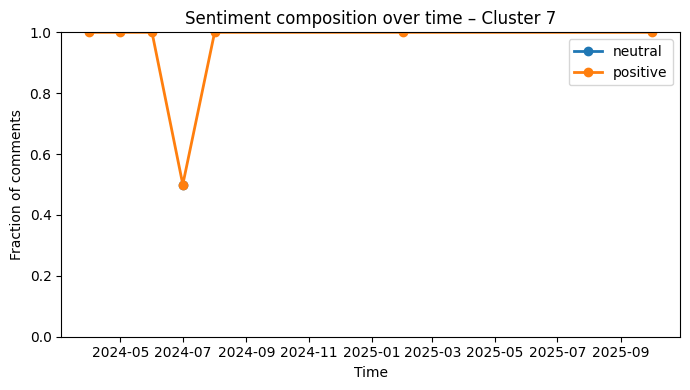

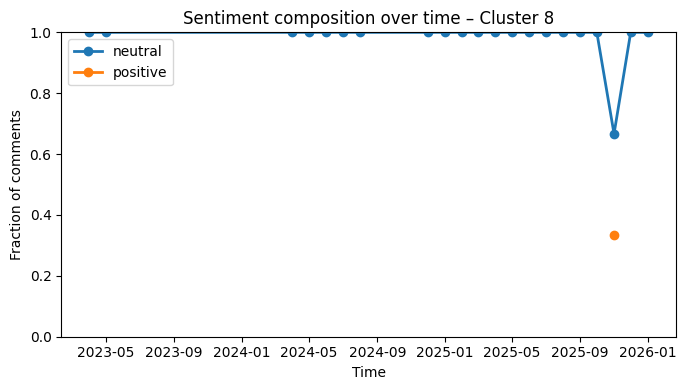

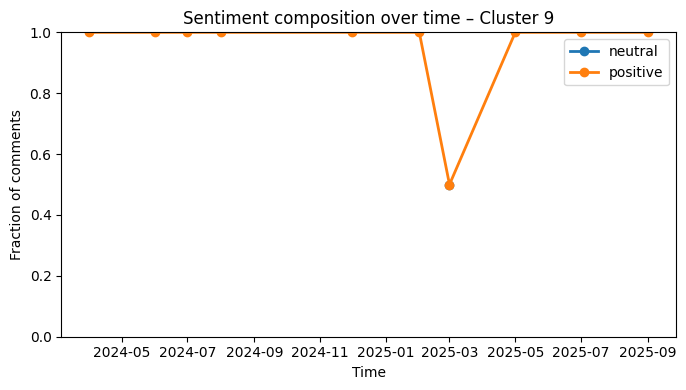

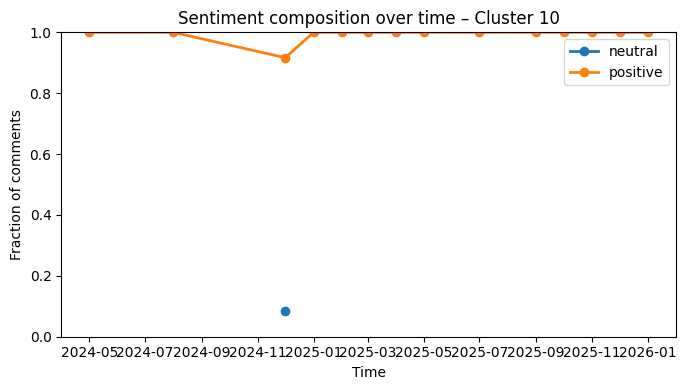

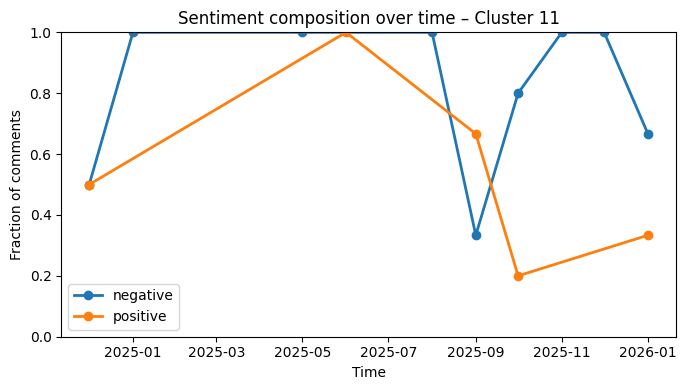

In [ ]:
sentiment_order = ["negative", "neutral", "positive"]

for cluster_id in sorted(sentiment_time_all["cluster_hdb"].unique()):
    sub = sentiment_time_all[
        sentiment_time_all["cluster_hdb"] == cluster_id
    ].copy()

    sub["year_month"] = pd.to_datetime(sub["year_month"])

    plt.figure(figsize=(7, 4))

    for label in sentiment_order:
        line = sub[sub["sentiment_label"] == label]
        if not line.empty:
            plt.plot(
                line["year_month"],
                line["fraction"],
                marker="o",
                linewidth=2,
                label=label
            )

    plt.ylim(0, 1)
    plt.xlabel("Time")
    plt.ylabel("Fraction of comments")
    plt.title(f"Sentiment composition over time – Cluster {cluster_id}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Define a function to extract representative comments from each cluster using centroid similarity, engagement ranking, and random sampling for qualitative interpretation of cluster themes.

In [ ]:
def extract_representative_comments(
    df,
    embeddings,
    cluster_id,
    n_central=5,
    n_engaged=5,
    n_random=5,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    sub = df[df["cluster_hdb"] == cluster_id].copy()
    idx = sub.index.to_numpy()
    sub_emb = embeddings[idx]

    # ---- 1) Central comments (closest to centroid) ----
    centroid = sub_emb.mean(axis=0, keepdims=True)
    distances = np.linalg.norm(sub_emb - centroid, axis=1)

    central_idx = idx[np.argsort(distances)[:n_central]]

    # ---- 2) High-engagement comments ----
    engaged = sub.sort_values(
        ["diggcount", "reply_count"],
        ascending=False
    ).head(n_engaged).index.to_numpy()

    # ---- 3) Random within cluster ----
    remaining = list(set(idx) - set(central_idx) - set(engaged))
    if len(remaining) >= n_random:
        random_idx = rng.choice(remaining, size=n_random, replace=False)
    else:
        random_idx = np.array(remaining)

    # Combine & deduplicate
    final_idx = list(dict.fromkeys(
        list(central_idx) + list(engaged) + list(random_idx)
    ))

    cols = [
        "text_clean",
        "diggcount",
        "reply_count",
        "timestamp",
        "sentiment_label"
    ]

    return df.loc[final_idx, cols].reset_index(drop=True)

Extract representative comments for selected clusters (4 and 11) to qualitatively validate cluster meanings and interpret discussion themes.

In [ ]:
cluster_4_samples = extract_representative_comments(
    df, X, cluster_id=4
)

cluster_11_samples = extract_representative_comments(
    df, X, cluster_id=11
)

Display representative comments for clusters 4 and 11 to examine real examples of clustered discussions and validate semantic grouping.

In [ ]:
print("=== Cluster 4 representative comments ===")
display(cluster_4_samples)

print("=== Cluster 11 representative comments ===")
display(cluster_11_samples)

=== Cluster 4 representative comments ===


,text_clean,diggcount,reply_count,timestamp,sentiment_label
0,Did the rashes itch?,4,0,2025-12-19 06:45:28+00:00,neutral
1,was the rash itchy?,4,0,2025-12-14 21:39:30+00:00,negative
2,did your rash itch?,3,0,2025-12-04 02:41:43+00:00,negative
3,does the rash itch ? or not,1,0,2025-09-12 13:48:12+00:00,negative
4,is the rash itchy or came on its own,1,1,2025-09-23 03:06:55+00:00,negative
5,I have dermatitis like all over my body and I ...,286,2,2025-10-15 05:14:05+00:00,positive
6,it happens to us who have low immune systems n...,93,2,2025-09-05 21:37:31+00:00,neutral
7,I get those type of rashes off and on but I ge...,33,6,2025-09-06 17:54:09+00:00,neutral
8,did the rash on your neck hurt? could you pop it?,25,2,2025-09-03 03:18:40+00:00,negative
9,I have never heard of a rash from HIV… and I’v...,7,0,2025-09-29 22:07:10+00:00,positive


=== Cluster 11 representative comments ===


,text_clean,diggcount,reply_count,timestamp,sentiment_label
0,I’m so sorry this happened to you 💔,1491,2,2025-09-02 17:45:00+00:00,negative
1,I’m so sorry this happened to you 🥺❤️,3,1,2024-12-09 15:09:35+00:00,negative
2,I’m so sorry this happened to you. 😔,0,0,2026-01-29 21:56:09+00:00,negative
3,i’m so sorry this happened to you,3,0,2025-11-15 08:41:11+00:00,negative
4,Im so sorry this happened to you,1,0,2025-10-26 16:05:45+00:00,negative
5,"My sweet Cody, you did not deserve what happen...",357,2,2025-09-03 04:26:30+00:00,positive
6,you sound like a sweet person. im sorry this h...,18,1,2025-09-05 23:33:14+00:00,positive
7,"I am so sorry this happened to you, but you ar...",15,1,2025-09-06 03:58:40+00:00,positive
8,I am so sorry this happened to you. I hope you...,7,1,2025-09-06 00:27:58+00:00,positive
9,Thank god you’re okay I’m so happy you feel be...,0,1,2024-12-14 01:35:53+00:00,positive


Louvain

In [ ]:
!pip -q install networkx python-louvain scikit-learn